# Бинарная классификация

Обучим логистическую регрессию для выявления злокачественных опухолей. Проверим баланс классов, рассчитаем метрики, построим confusion matrix и ROC-кривую, затем изучим коэффициенты модели.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## Данные и баланс классов

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Размер: (569, 30)
Пропуски: 0


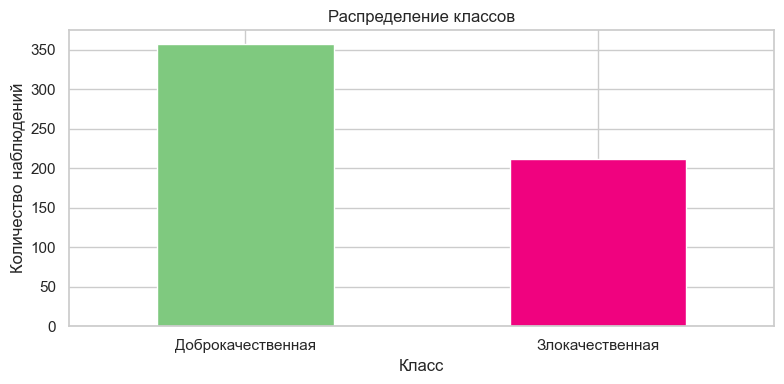

In [2]:
dataset = load_breast_cancer(as_frame=True)
features = dataset.data
target = (dataset.target == 0).astype(int)
class_names = {0: "Доброкачественная", 1: "Злокачественная"}

display(features.head())
print("Размер:", features.shape)
print("Пропуски:", int(features.isna().sum().sum()))

target.map(class_names).value_counts().plot.bar(figsize=(8, 4), color=["#7fc97f", "#f0027f"])
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество наблюдений")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Обучение

In [3]:
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", max_iter=3000, random_state=42)),
])
pipeline.fit(train_features, train_target)
prediction = pipeline.predict(test_features)
probability = pipeline.predict_proba(test_features)[:, 1]

## Метрики

In [4]:
pd.Series({
    "accuracy": accuracy_score(test_target, prediction),
    "precision": precision_score(test_target, prediction),
    "recall": recall_score(test_target, prediction),
    "f1": f1_score(test_target, prediction),
    "roc_auc": roc_auc_score(test_target, probability),
}).to_frame("value")

,value
accuracy,0.973684
precision,0.975610
recall,0.952381
f1,0.963855
roc_auc,0.995370


## Матрица ошибок и ROC-кривая

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


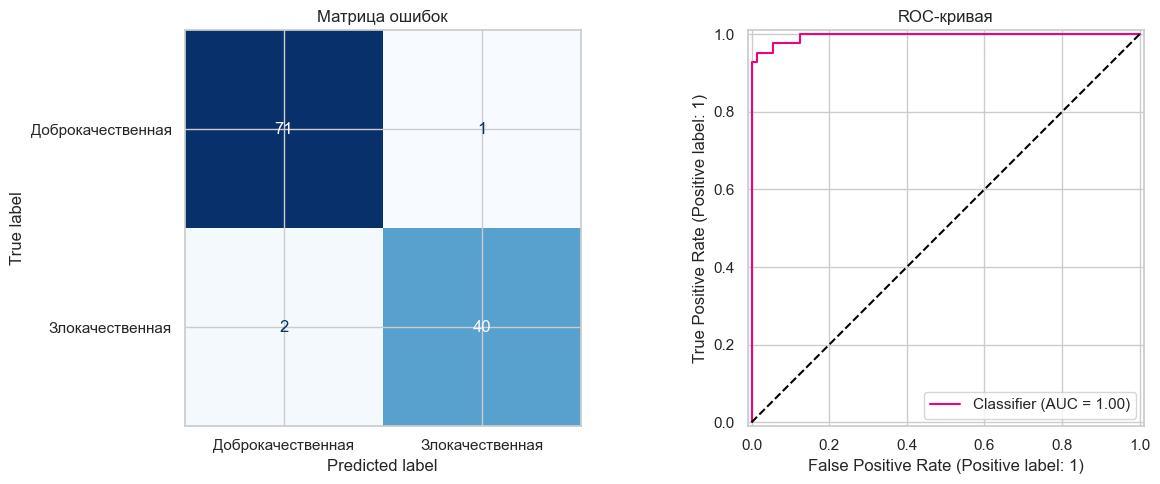

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    test_target,
    prediction,
    display_labels=[class_names[0], class_names[1]],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title("Матрица ошибок")

RocCurveDisplay.from_predictions(test_target, probability, ax=axes[1], color="#f0027f")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="black")
axes[1].set_title("ROC-кривая")
plt.tight_layout()
plt.show()

## Влияние признаков

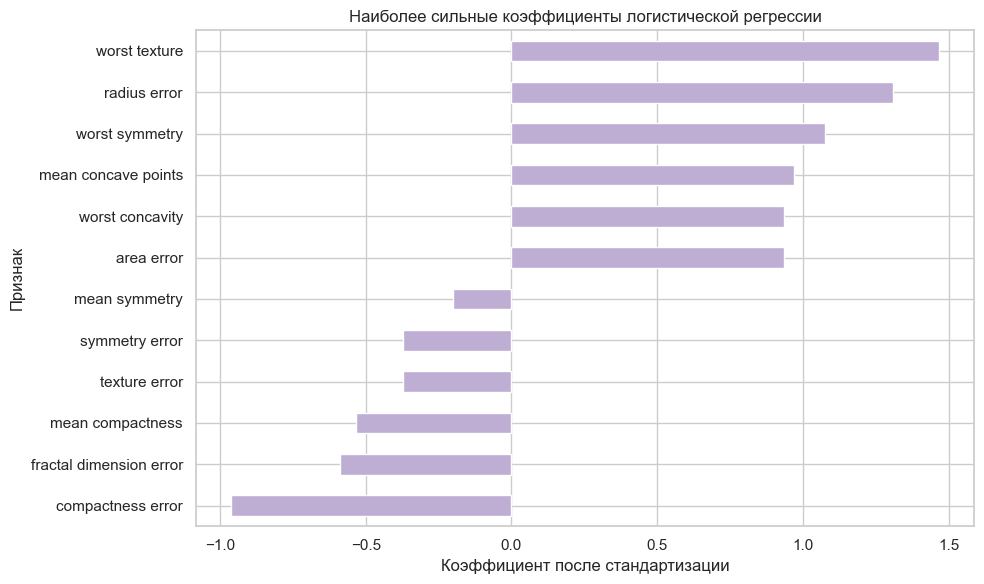

In [6]:
coefficients = pd.Series(
    pipeline.named_steps["model"].coef_[0],
    index=features.columns,
).sort_values()
important_coefficients = pd.concat([coefficients.head(6), coefficients.tail(6)])

important_coefficients.plot.barh(figsize=(10, 6), color="#beaed4")
plt.title("Наиболее сильные коэффициенты логистической регрессии")
plt.xlabel("Коэффициент после стандартизации")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

## Вывод

ROC-AUC оценивает качество ранжирования по всем возможным порогам, а precision и recall показывают цену разных типов ошибок. Для медицинской задачи особенно важно контролировать пропуск положительного класса, поэтому recall нужно рассматривать вместе с confusion matrix.